In [14]:
from typing import TypedDict, List
from langgraph.graph import StateGraph
import math

In [18]:
class AgentState(TypedDict):  # it can be anything like class fuckYou
    # how to have multiple inputs?
    values: List[int]
    name: str
    result: str
    operation:str
    
    
    
    

In [19]:
def process_values(state:AgentState)->AgentState:
    """
    This function gets multiple inputs 
    """
    total = state['values'] 
    if state['opeartion'] == "+":
        total = sum(total)
    else:
        total *= math.prod(total)
    state['state'] = f"Hi {state['name']}" + f", your answer is{total}" 
    return state

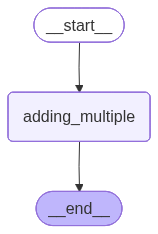

In [11]:
graph = StateGraph(AgentState)
graph.add_node("adding_multiple", process_values)
graph.set_entry_point("adding_multiple")
graph.set_finish_point("adding_multiple")

app = graph.compile()


from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
answer = app.invoke({"values":[1,2,3,4,5], "name":"Brian"})

{'values': [1, 2, 3, 4, 5], 'name': 'Brian'}


In [13]:
print(answer['result'])

The sum of the value is 15 from Brian
